## Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings("ignore")
%matplotlib inline

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}")


## Data Loading

In [ ]:
BASE = "/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset"

dirs = {
    "Mild Demented":     f"{BASE}/MildDemented",
    "Moderate Demented": f"{BASE}/ModerateDemented",
    "Non Demented":      f"{BASE}/NonDemented",
    "Very MildDemented": f"{BASE}/VeryMildDemented",
}

filepaths, labels = [], []
for label, path in dirs.items():
    for f in os.listdir(path):
        filepaths.append(os.path.join(path, f))
        labels.append(label)

df = pd.DataFrame({"filepaths": filepaths, "labels": labels})
print(df.head())
print(df["labels"].value_counts())
print(f"Shape: {df.shape}")

                                           filepaths         labels
0  /kaggle/input/augmented-alzheimer-mri-dataset/...  Mild Demented
1  /kaggle/input/augmented-alzheimer-mri-dataset/...  Mild Demented
2  /kaggle/input/augmented-alzheimer-mri-dataset/...  Mild Demented
3  /kaggle/input/augmented-alzheimer-mri-dataset/...  Mild Demented
4  /kaggle/input/augmented-alzheimer-mri-dataset/...  Mild Demented
labels
Non Demented         9600
Mild Demented        8960
Very MildDemented    8960
Moderate Demented    6464
Name: count, dtype: int64
Shape: (33984, 2)


## Exploratory Data Analysis

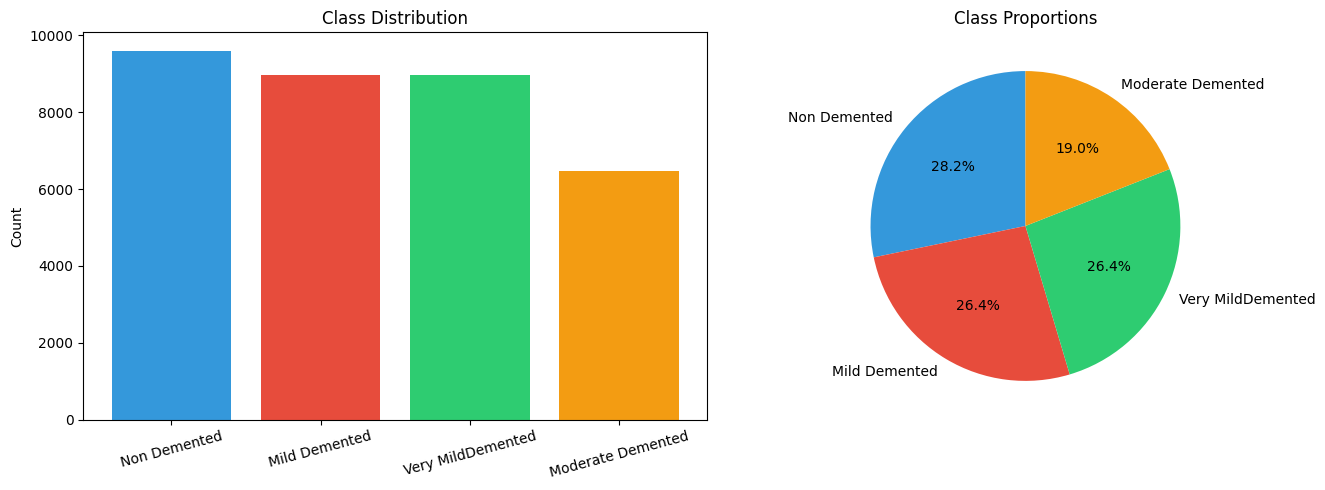

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["labels"].value_counts()
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=15)
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Class Proportions")
plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Val:   {val_df.shape}")

Train: (19030, 2)
Test:  (10196, 2)
Val:   (4758, 2)


In [ ]:
gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train = gen.flow_from_dataframe(train_df, x_col="filepaths", y_col="labels",
                                target_size=(224, 224), color_mode="rgb",
                                class_mode="categorical", batch_size=32, shuffle=False)

test = gen.flow_from_dataframe(test_df, x_col="filepaths", y_col="labels",
                               target_size=(224, 224), color_mode="rgb",
                               class_mode="categorical", batch_size=32, shuffle=False)

val = gen.flow_from_dataframe(val_df, x_col="filepaths", y_col="labels",
                              target_size=(224, 224), color_mode="rgb",
                              class_mode="categorical", batch_size=32, shuffle=False)

classes = list(train.class_indices.keys())
print(classes)

Found 19030 validated image filenames belonging to 4 classes.
Found 10196 validated image filenames belonging to 4 classes.
Found 4758 validated image filenames belonging to 4 classes.
['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']


## Sample Images

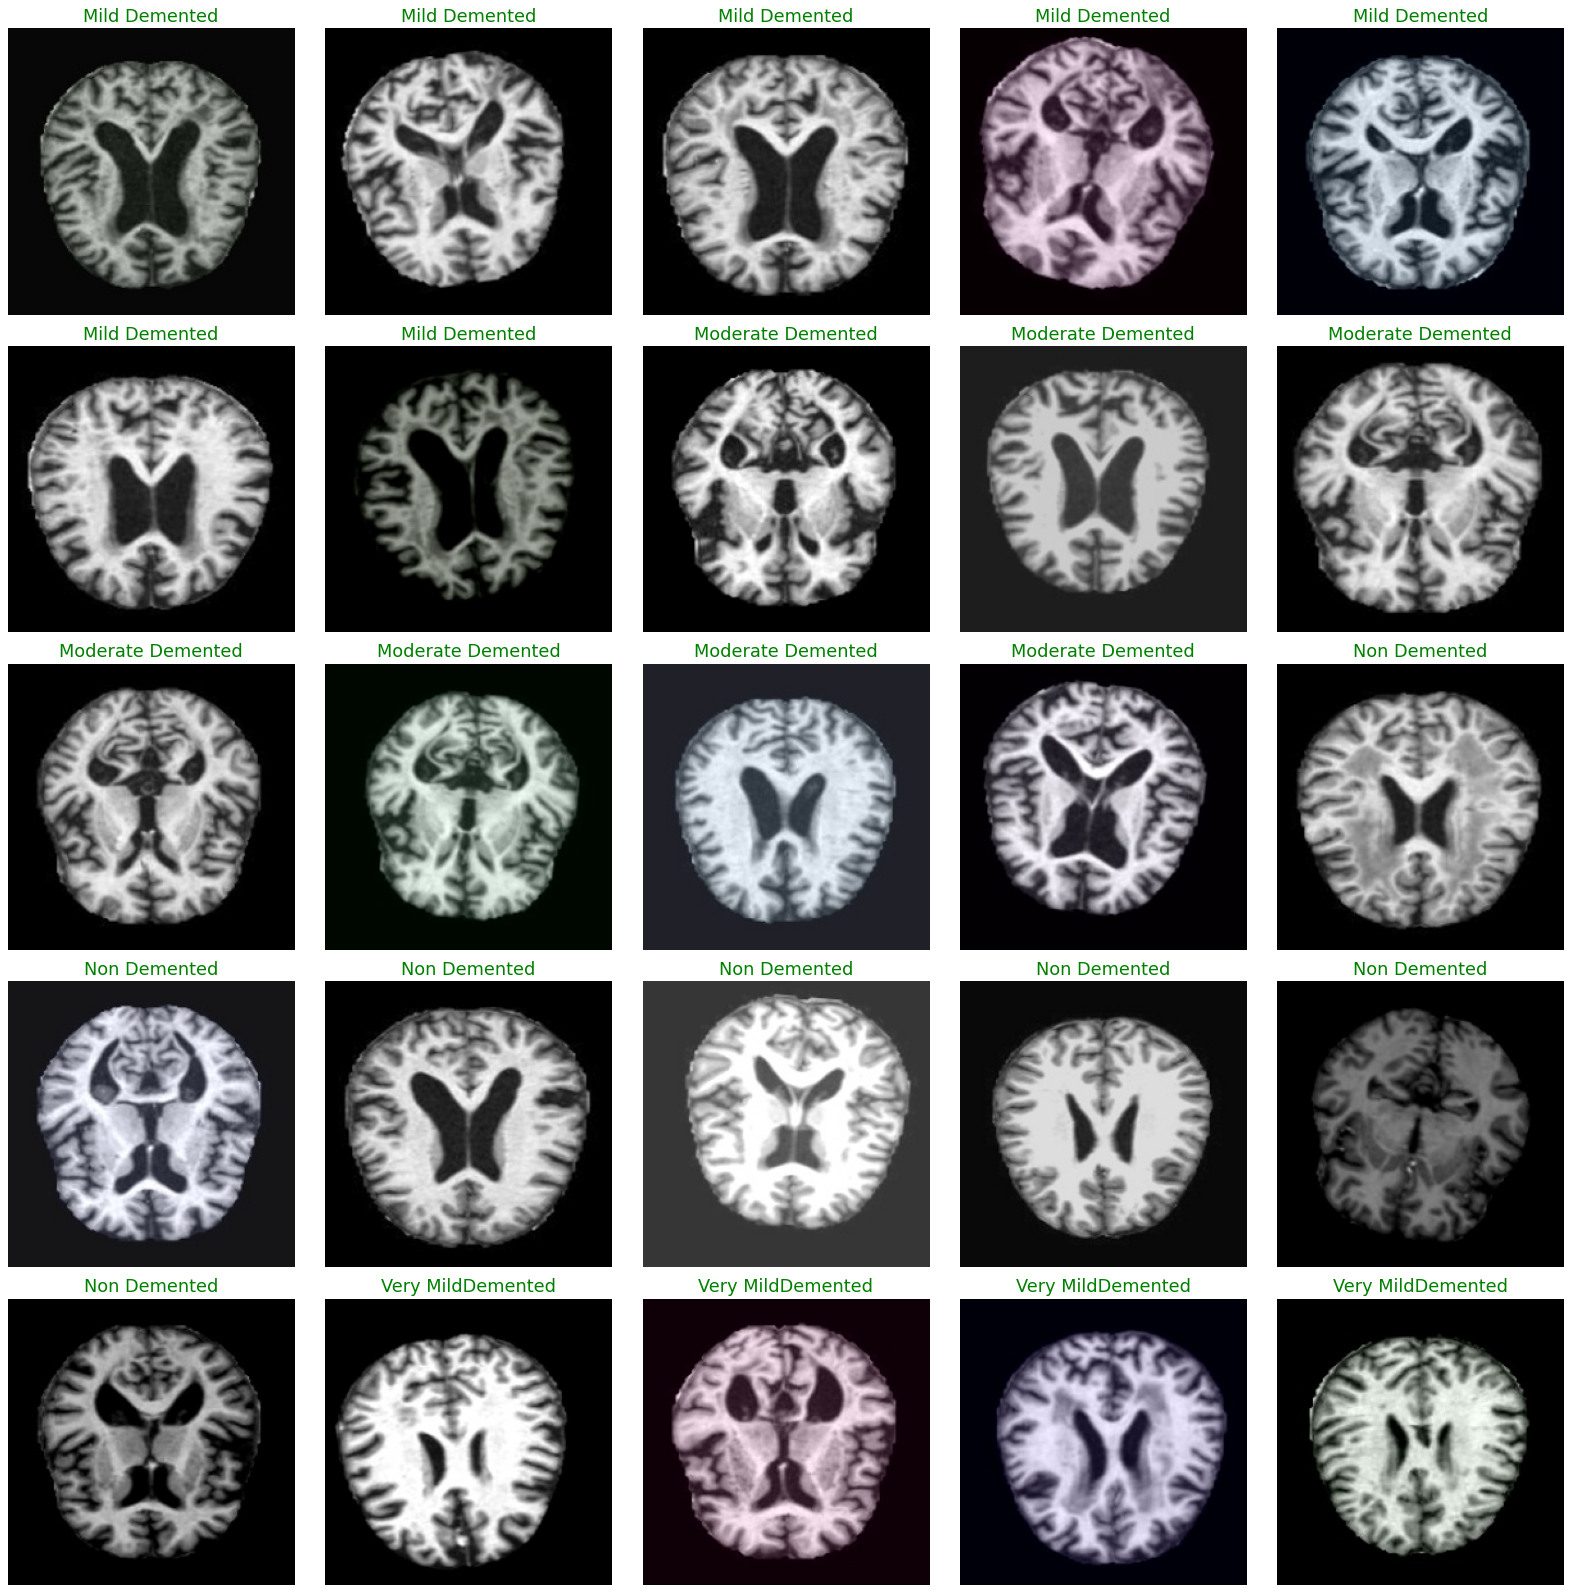

In [ ]:
images, batch_labels = next(train)
plt.figure(figsize=(20, 20))
for i in range(min(25, len(batch_labels))):
    plt.subplot(5, 5, i + 1)
    plt.imshow((images[i] + 1) / 2)
    plt.title(classes[np.argmax(batch_labels[i])], color="green", fontsize=16)
    plt.axis("off")
plt.show()

## Model Architecture

In [ ]:
model = keras.models.Sequential([
    keras.layers.Conv2D(128, (8,8), strides=(3,3), activation="relu", input_shape=(224,224,3)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(256, (5,5), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D((3,3)),

    keras.layers.Conv2D(256, (3,3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(256, (1,1), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(256, (1,1), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(512, (3,3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D((2,2)),

    keras.layers.Conv2D(512, (3,3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(512, (3,3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D((2,2)),

    keras.layers.Conv2D(512, (3,3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation="softmax")
])

model.compile(loss="categorical_crossentropy",
              optimizer=tf.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 73, 73, 128)       24704     
                                                                 
 batch_normalization (BatchN  (None, 73, 73, 128)      512       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 73, 73, 256)       819456    
                                                                 
 batch_normalization_1 (Batc  (None, 73, 73, 256)      1024      
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 24, 24, 256)      0         
 )                                                               
                                                        

## Training

In [ ]:
history = model.fit(train, epochs=22, validation_data=val, validation_freq=1)

Epoch 1/22
850/850 [==============================] - 263s 295ms/step - loss: 1.3674 - accuracy: 0.4113 - val_loss: 1.0246 - val_accuracy: 0.5294
Epoch 2/22
850/850 [==============================] - 82s 97ms/step - loss: 0.9754 - accuracy: 0.5496 - val_loss: 0.8400 - val_accuracy: 0.6064
Epoch 3/22
850/850 [==============================] - 83s 97ms/step - loss: 0.8266 - accuracy: 0.6118 - val_loss: 0.7332 - val_accuracy: 0.6540
Epoch 4/22
850/850 [==============================] - 83s 98ms/step - loss: 0.7476 - accuracy: 0.6522 - val_loss: 0.6657 - val_accuracy: 0.6907
Epoch 5/22
850/850 [==============================] - 85s 100ms/step - loss: 0.6747 - accuracy: 0.6898 - val_loss: 0.6021 - val_accuracy: 0.7278
Epoch 6/22
850/850 [==============================] - 85s 100ms/step - loss: 0.5901 - accuracy: 0.7339 - val_loss: 0.5291 - val_accuracy: 0.7733
Epoch 7/22
850/850 [==============================] - 83s 97ms/step - loss: 0.5148 - accuracy: 0.7761 - val_loss: 0.4678 - val_accur

## Evaluation

In [ ]:
model.evaluate(test, verbose=1)

319/319 [==============================] - 21s 65ms/step - loss: 0.2519 - accuracy: 0.9323
[0.25192558765411377, 0.9323263764381409]


In [ ]:
model.save("alzheimer_cnn_model.h5")

Model saved successfully.


In [ ]:
pred = np.argmax(model.predict(test), axis=1)
label_map = {v: k for k, v in train.class_indices.items()}
pred_labels = [label_map[k] for k in pred]

319/319 [==============================] - 20s 62ms/step


## Training Curves

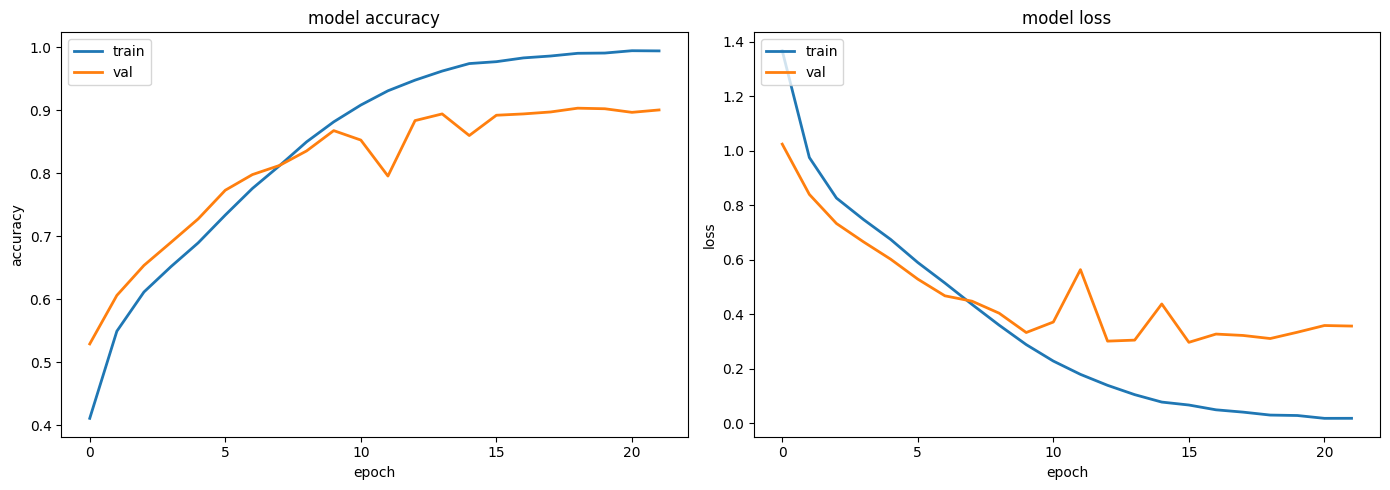

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

## Classification Report

In [ ]:
y_test = test_df["labels"].values
print(classification_report(y_test, pred_labels))
print("Accuracy of the Model:", "{:.1f}%".format(accuracy_score(y_test, pred_labels) * 100))

                   precision    recall  f1-score   support

    Mild Demented       0.95      0.93      0.94      2693
Moderate Demented       0.99      0.99      0.99      1977
     Non Demented       0.93      0.92      0.92      2811
Very MildDemented       0.88      0.91      0.89      2715

         accuracy                           0.93     10196
        macro avg       0.94      0.94      0.94     10196
     weighted avg       0.93      0.93      0.93     10196

Accuracy of the Model: 93.2%


## Confusion Matrix

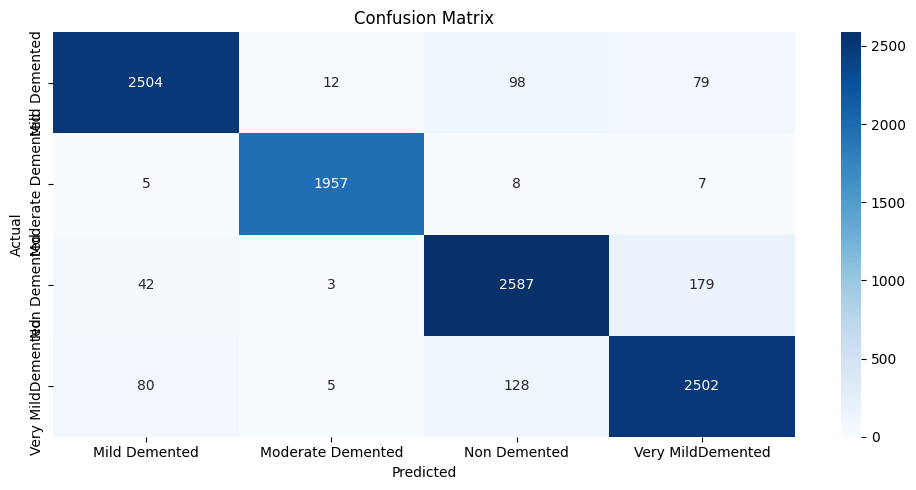

In [ ]:
cm = confusion_matrix(y_test, pred_labels)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt="g", vmin=0, cmap="Blues")
plt.xticks(ticks=[0.5,1.5,2.5,3.5], labels=classes)
plt.yticks(ticks=[0.5,1.5,2.5,3.5], labels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()